Прибор Лермантова: определение зависимости удлинения проволоки от массы груза (силы натяжения).

Исходная зависимость: положение лазерной метки от массы добавленного груза

In [120]:
file = open("1.1.txt")
A = [[float(line.split()[0]), int(line.split()[1])-198] for line in file]
file.close()
print(A)

[[0.0, 0], [478.3, 41], [245.7, 58], [245.4, 71], [245.5, 84], [245.4, 95], [245.6, 109], [-245.6, 96], [-245.4, 83], [-245.5, 71], [-245.4, 58], [-245.7, 43], [-478.3, 0]]


Заменим добавленные массы на текущие массы огрузки проволки

In [121]:
s = 0
for i in range(len(A)):
    s+=A[i][0]
    A[i][0] = s
print(A)


[[0.0, 0], [478.3, 41], [724.0, 58], [969.4, 71], [1214.9, 84], [1460.3000000000002, 95], [1705.9, 109], [1460.3000000000002, 96], [1214.9, 83], [969.4000000000001, 71], [724.0000000000001, 58], [478.3000000000001, 43], [1.1368683772161603e-13, 0]]


Имеем зависимость смещения метки (мм) от массы (г)

Удалим крайние значения (выпрямление проволоки)

In [114]:
A.pop(0)
A.pop()

[-1.1368683772161603e-13, 1]

Рассчитаем удлинение и вес

In [115]:
dm = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
db = 0.5

g=9.8

# длина рычага, мм
r = 13
dr = 0.5
er = dr/r

# расстояние от зеркала до лазера, мм
h = 1476
dh = 1
eh = dh/h

#
X = list()
Y = list()
dX = list()
dY = list()
for i in range(len(A)):
    b = A[i][1]
    m = A[i][0]
    l = b*r/(2*h) * 0.001 #метры
    eb = db/b
    em = dm[i]/m
    el = (er**2 + eh**2 + eb**2)**0.5
    dl = l*el
    print(l, dl)

    P = m*0.001*g
    eP = em
    dP = P*eP
    print(P, dP)

    Y.append(l)
    X.append(P)
    dY.append(dl)
    dX.append(dP)
    
    
    print('***')
print(X)
print(dX)
print(Y)
print(dY)
    
    
    
    

0.00012330623306233064 5.229444103504217e-06
2.40688 0.00294
***
0.00020257452574525746 8.097652591514294e-06
4.8118 0.00392
***
0.0002598238482384824 1.0234445878536476e-05
7.217700000000001 0.0049
***
0.0003258807588075881 1.2727730674934967e-05
9.622620000000001 0.005880000000000001
***
0.000383130081300813 1.490163466604786e-05
12.03048 0.006860000000000001
***
0.00048441734417344176 1.8763967657565357e-05
16.71782 0.007840000000000001
***
0.000383130081300813 1.490163466604786e-05
12.03048 0.006860000000000001
***
0.0003258807588075881 1.2727730674934967e-05
9.62262 0.005880000000000001
***
0.00026422764227642276 1.0399945626102475e-05
7.2177 0.004900000000000001
***
0.00020257452574525746 8.097652591514294e-06
4.811799999999999 0.003920000000000001
***
0.00013211382113821138 5.538590083954973e-06
2.406879999999999 0.00294
***
[2.40688, 4.8118, 7.217700000000001, 9.622620000000001, 12.03048, 16.71782, 12.03048, 9.62262, 7.2177, 4.811799999999999, 2.406879999999999]
[0.00294, 0.003

In [116]:
def mnk(X, Y):
    N = len(X)
    
    XY = [X[i]*Y[i] for i in range(N)]
    X2 = [x*x for x in X]
    Y2 = [y*y for y in Y]
    
    _xy = sum(XY)/len(XY)
    _x = sum(X)/N
    _y = sum(Y)/N
    _x2 = sum(X2)/N
    _y2 = sum(Y2)/N

    b = (_xy - _x*_y)/(_x2 - _x*_x)
    a = _y - b*_x

    sb = (((_y2 - _y**2)/(_x2 - _x**2) - b**2)*(1/N))**0.5
    sa = sb*(_x2-_x*_x)**0.5
    
    return (b, a, sb, sa)

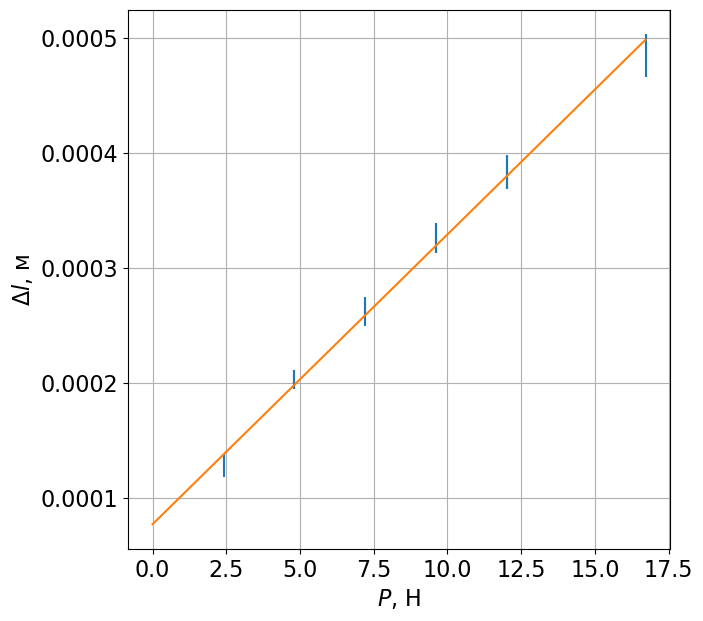

Угловой коэффицент: 2.521256023194283e-05
Погрешность углового коэффицента: 5.22862325545441e-07
Свободный член: 7.688583640185777e-05
Погрешность свободного члена: 2.2172064880707158e-06


In [117]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = False
plt.figure(figsize=(7,7))

plt.ylabel(r"$\Delta l$, м")
plt.xlabel("$P$, Н")

# данные
x = X

y = Y

plt.errorbar(x,y, yerr=dY, xerr=dX, fmt= ',')

plt.grid(visible=True, which='major', axis='both', alpha=1)
plt.grid(visible=True, which='minor', axis='both', alpha=1)

k, a, sk, sa = mnk(X,Y)

xline = np.linspace(0, max(X) ,100)
yline = xline*k + a
plt.plot(xline, yline, label="Средняя")

plt.savefig('plot1.png')

plt.show()
print("Угловой коэффицент:", k)
print("Погрешность углового коэффицента:", sk)
print("Свободный член:", a)
print("Погрешность свободного члена:", sa)

In [119]:
R = 0.365
dR = 0.005
eR = dR/R
R/=1000
dR = R*eR

l = 1.760
dl =0.002
el = dl/l

ek = ((max(dY)/max(Y))**2 + (max(dX)/max(X))**2)**0.5

dk = (sk**2 + (k*ek)**2)**0.5

ek = dk/k


E = l/(3.1415*(R**2)*k)
eE = (el**2+ek**2+4*eR**2)**0.5
dE = E*eE
print('Модуль Юнга', E/10**9)
print('Его погрешность', dE/10**9)
print('Его относительная погрешность', eE*100, '%')

Модуль Юнга 166.79112043770635
Его погрешность 8.638754225460033
Его относительная погрешность 5.179384971327932 %
